<a href="https://www.kaggle.com/code/lalit7881/student-exam-performance-analysis?scriptVersionId=302547691" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/grandmaster07/student-exam-performance-dataset-analysis/StudentPerformanceFactors.csv


## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/grandmaster07/student-exam-performance-dataset-analysis/StudentPerformanceFactors.csv')

## View Dataset

In [3]:
df.head()        # First 5 rows
df.tail()        # Last 5 rows

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


## Dataset Information

In [4]:
df.info()        # Column types and non-null values
df.shape         # Rows and columns
df.columns       # Column names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

## Statistical Summary

In [5]:
df.describe()    # Mean, std, min, max etc.

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Check Missing Values

In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

## Fill Missing Values

In [7]:
df = df.fillna(df.mean(numeric_only=True))

## Unique Values

In [8]:
df.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

In [9]:
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)

df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)

df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

In [10]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [12]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Correlation

In [13]:
df.corr(numeric_only=True)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


## EDA

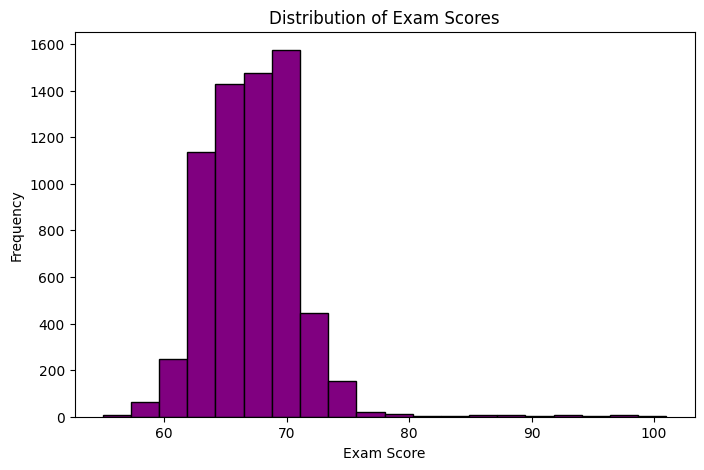

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Exam_Score'], bins=20, color='purple', edgecolor='black')
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

## Boxplot – Exam Score by Gender

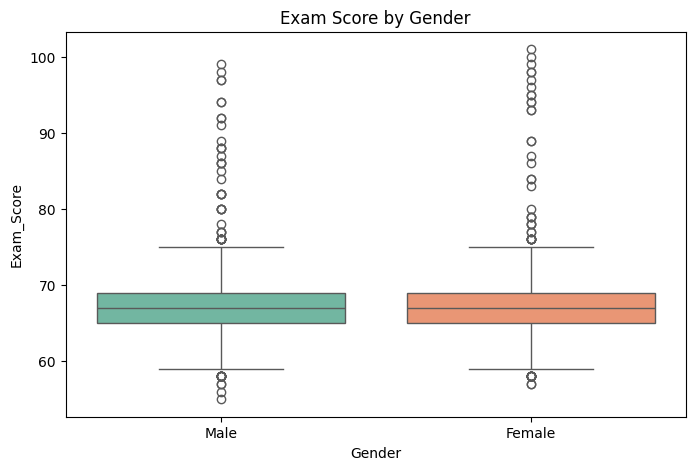

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='Exam_Score', data=df, palette='Set2')
plt.title("Exam Score by Gender")
plt.show()

## Scatter Plot – Hours Studied vs Exam Score

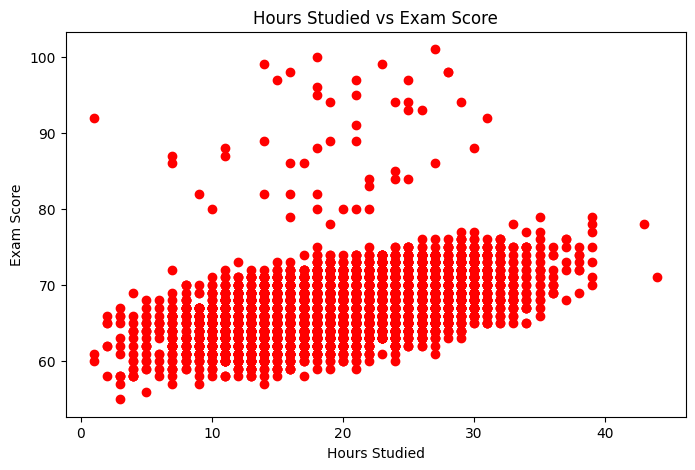

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='red')
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

## Bar Plot – Average Score by Motivation Level

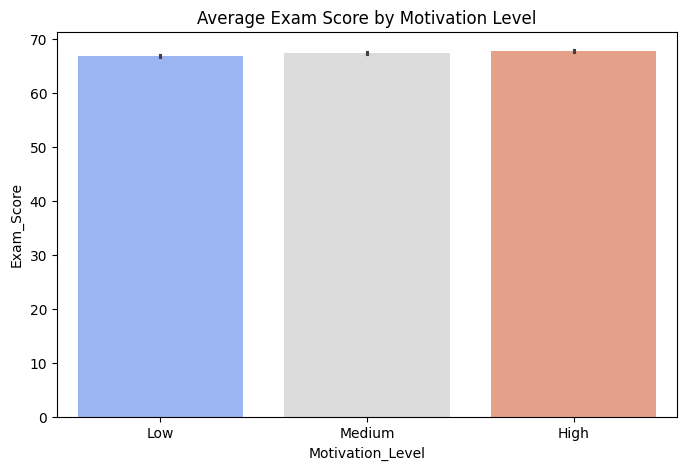

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(x='Motivation_Level', y='Exam_Score', data=df, palette='coolwarm')
plt.title("Average Exam Score by Motivation Level")
plt.show()

## Count Plot – Family Income Distribution

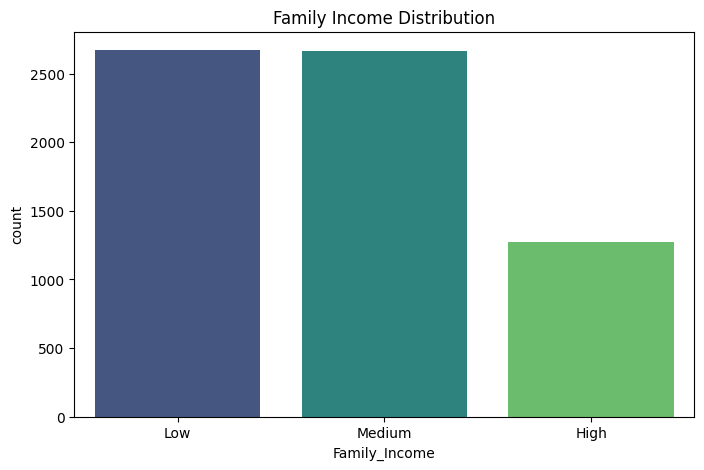

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Family_Income', data=df, palette='viridis')
plt.title("Family Income Distribution")
plt.show()

## Scatter Plot – Attendance vs Exam Score

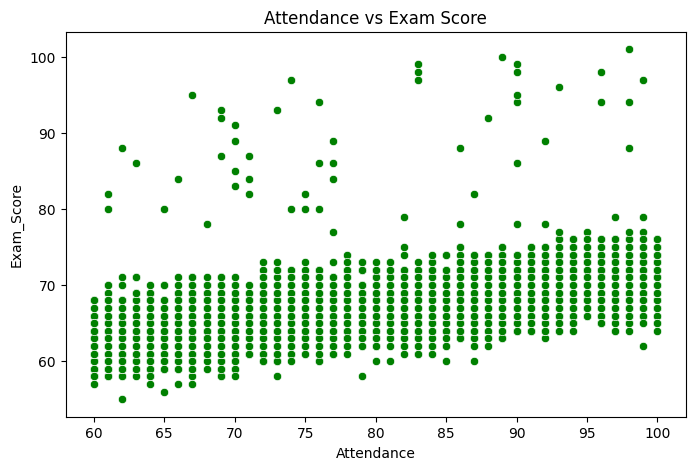

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Attendance', y='Exam_Score', data=df, color='green')
plt.title("Attendance vs Exam Score")
plt.show()

## Boxplot – Sleep Hours vs Exam Score

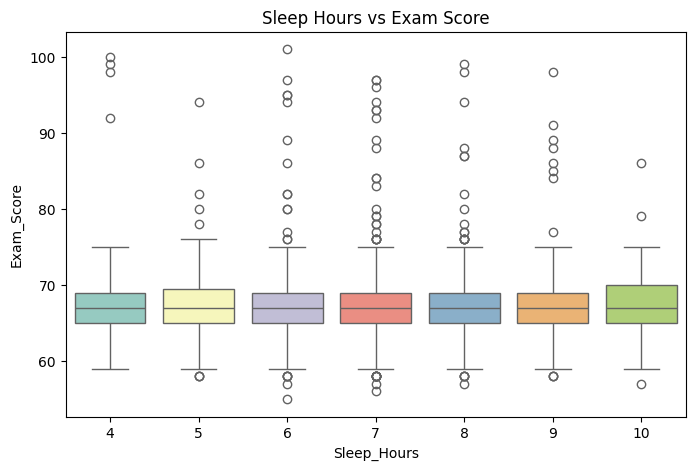

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Sleep_Hours', y='Exam_Score', data=df, palette='Set3')
plt.title("Sleep Hours vs Exam Score")
plt.show()

## Bar Plot – Teacher Quality vs Exam Score

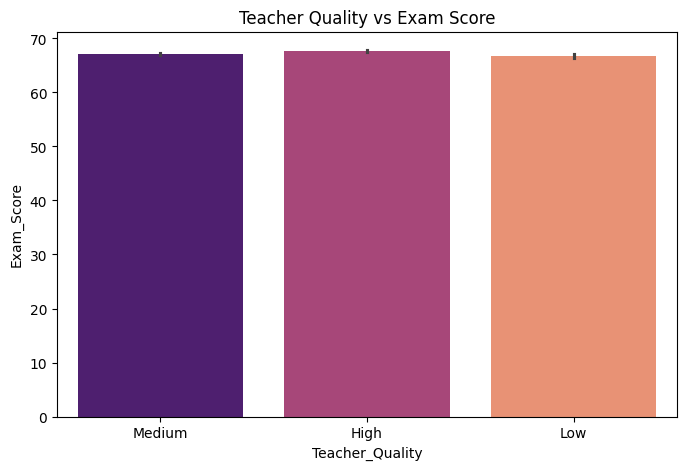

In [21]:
plt.figure(figsize=(8,5))
sns.barplot(x='Teacher_Quality', y='Exam_Score', data=df, palette='magma')
plt.title("Teacher Quality vs Exam Score")
plt.show()

## Correlation Heatmap

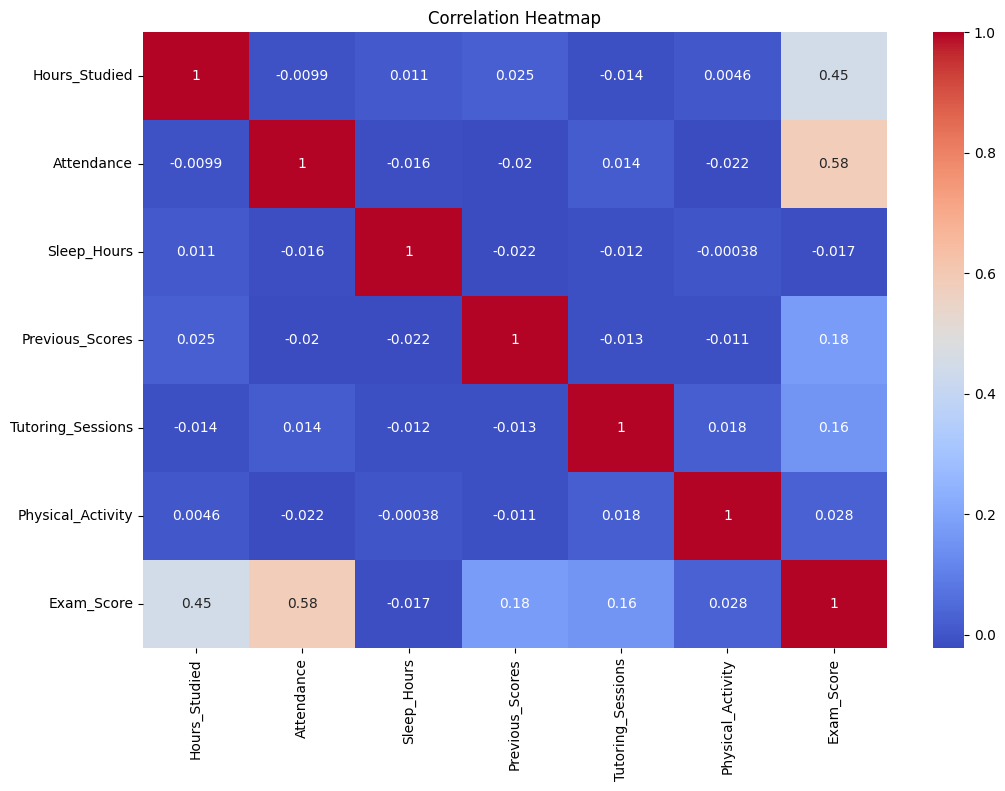

In [22]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Pairplot (Full Relationship Visualization)

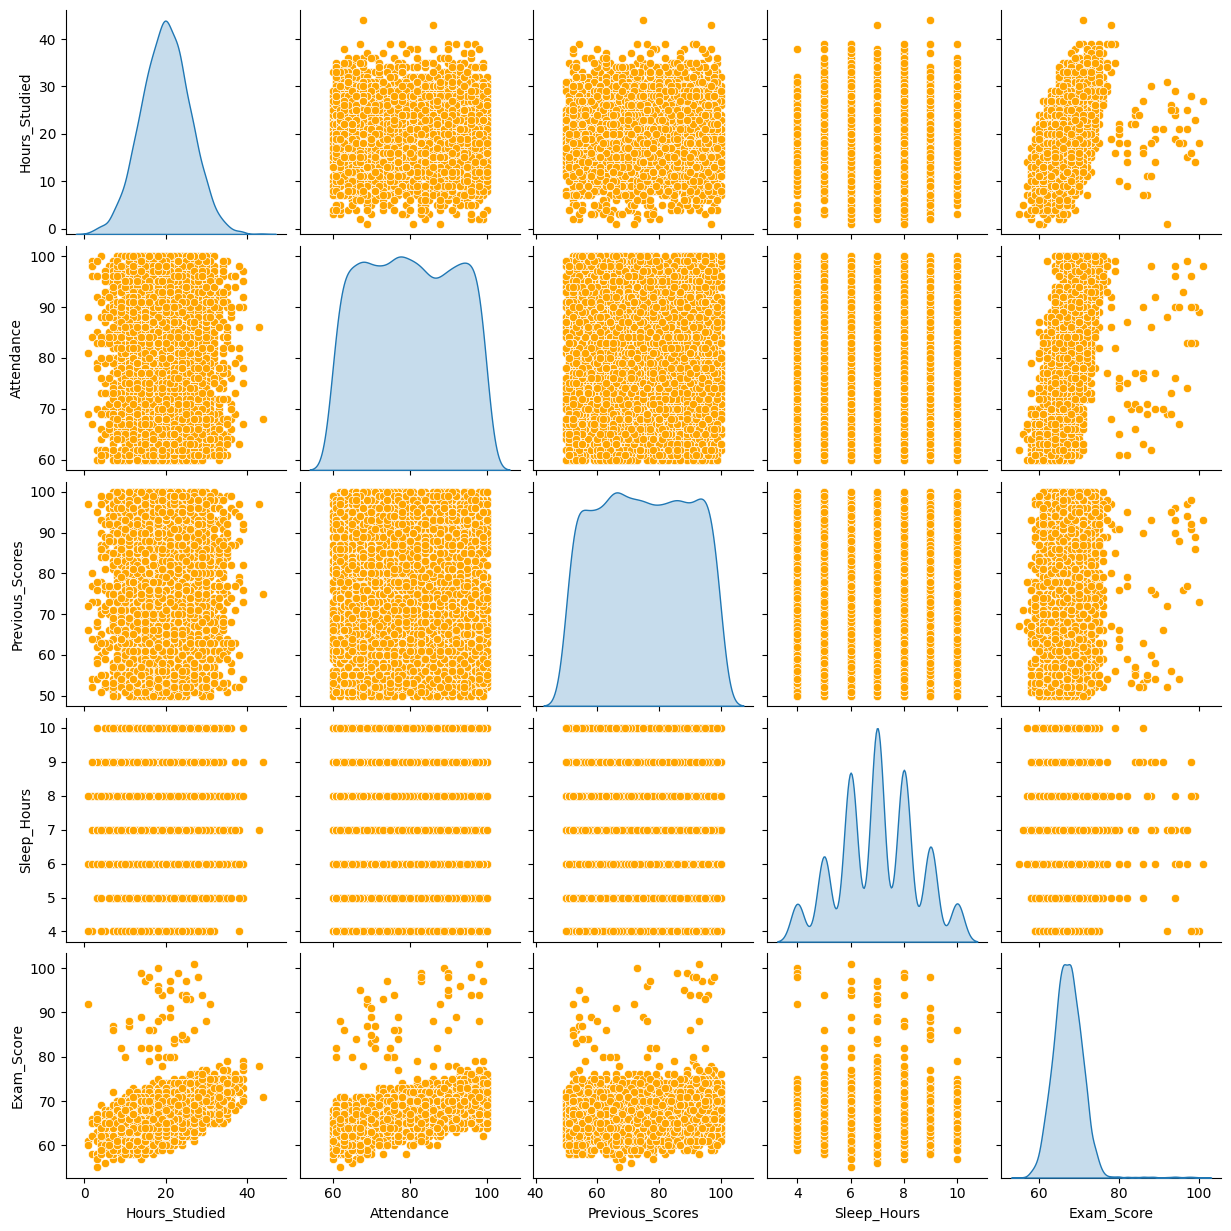

In [23]:
sns.pairplot(df[['Hours_Studied','Attendance','Previous_Scores','Sleep_Hours','Exam_Score']],
             diag_kind='kde',
             plot_kws={'color':'orange'})
plt.show()

## Pie Chart – Gender Distribution

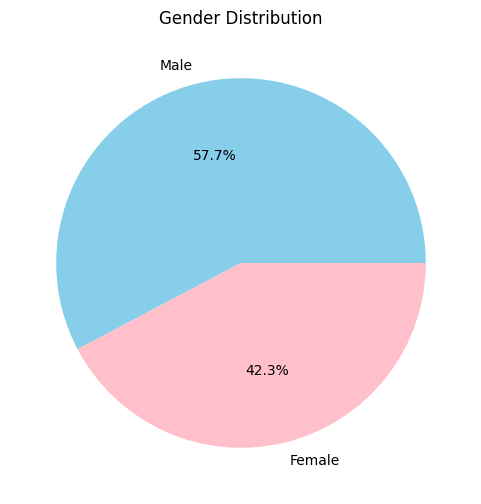

In [24]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','pink'],
    figsize=(6,6)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

## Line Plot – Hours Studied vs Score Trend

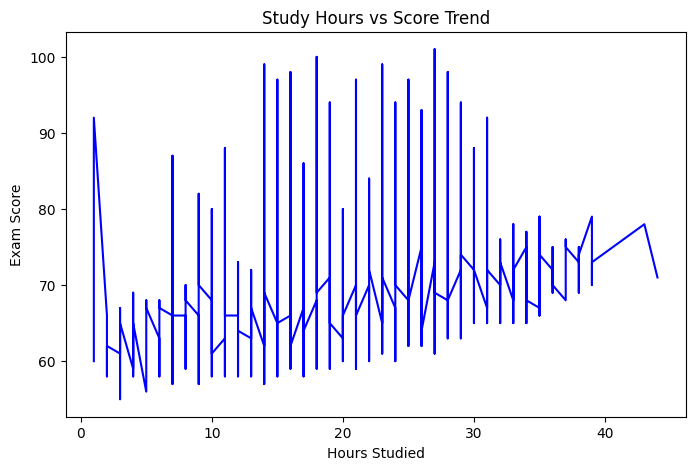

In [25]:
df_sorted = df.sort_values(by='Hours_Studied')

plt.figure(figsize=(8,5))
plt.plot(df_sorted['Hours_Studied'], df_sorted['Exam_Score'], color='blue')
plt.title("Study Hours vs Score Trend")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

## Violin Plot – Motivation Level vs Exam Score

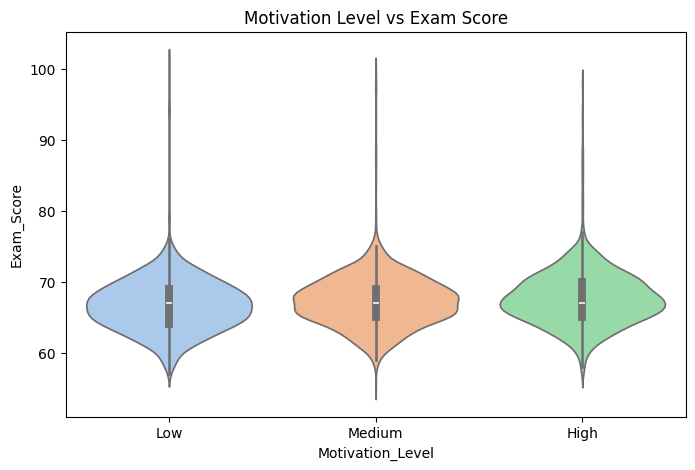

In [26]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Motivation_Level', y='Exam_Score', data=df, palette='pastel')
plt.title("Motivation Level vs Exam Score")
plt.show()

## Feature engineering

## Import Libraries

In [27]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

## Handle Missing Values

In [28]:
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

## Encode Categorical Variables

In [29]:
df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

## Create Target Variable

In [30]:
median_score = df_encoded['Exam_Score'].median()

df_encoded['Target'] = (df_encoded['Exam_Score'] >= median_score).astype(int)

## Define Features and Target

In [31]:
X = df_encoded.drop(['Exam_Score','Target'], axis=1)

y = df_encoded['Target']

## Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [33]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Multiple Machine Learning Models

In [34]:
model = SVC(kernel='rbf', probability=True)

model.fit(X_train, y_train)

SVC(probability=True)

In [35]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(n_estimators=200),

    "Support Vector Machine": SVC(kernel='rbf', probability=True),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}

## Train Models and Calculate Accuracy

In [36]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

    print("\n", "="*40)
    print("MODEL:", name)
    print("Accuracy:", round(accuracy*100,2), "%")


MODEL: Logistic Regression
Accuracy: 88.12 %

MODEL: Decision Tree
Accuracy: 82.0 %

MODEL: Random Forest
Accuracy: 90.02 %

MODEL: Support Vector Machine
Accuracy: 91.91 %

MODEL: KNN
Accuracy: 78.59 %

MODEL: Naive Bayes
Accuracy: 85.25 %


## Accuracy Comparison

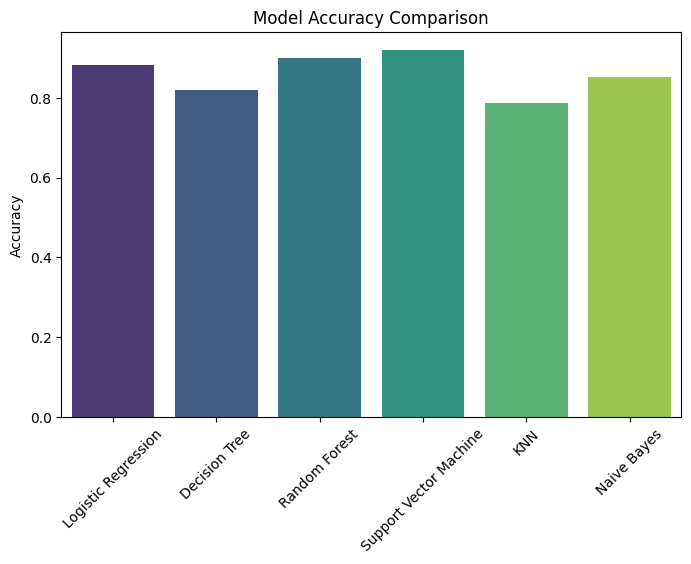

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    palette="viridis"
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=45)

plt.show()

## ROC Curve

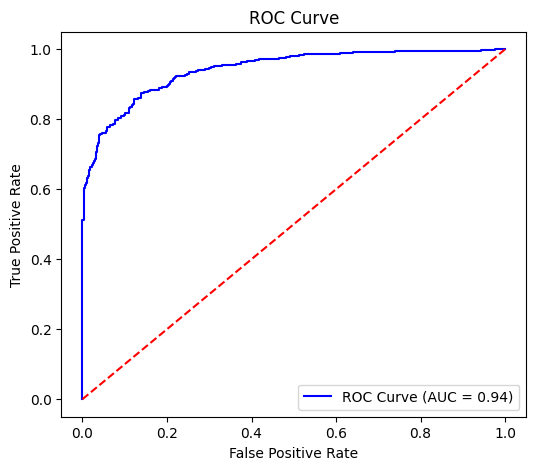

In [38]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = %0.2f)' % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Confusion Matrix

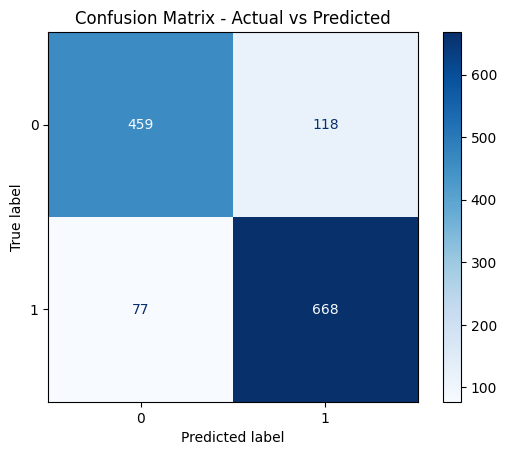

In [39]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Actual vs Predicted")

plt.show()

## Thank you..pls upvote!!!!!!